<a href="https://colab.research.google.com/github/Koushik2612/fds-lab/blob/main/k2lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Numeric Dissimilarity: 0.07459907651060027
Nominal Dissimilarity: 0


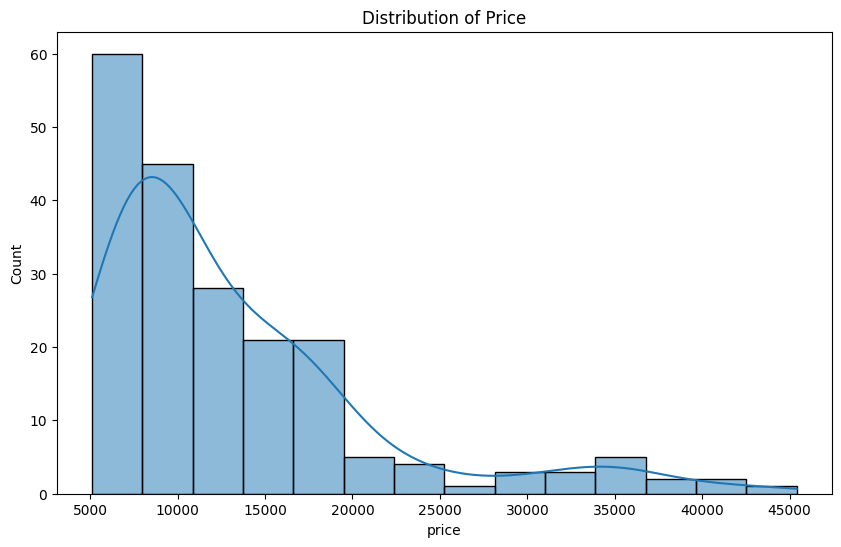

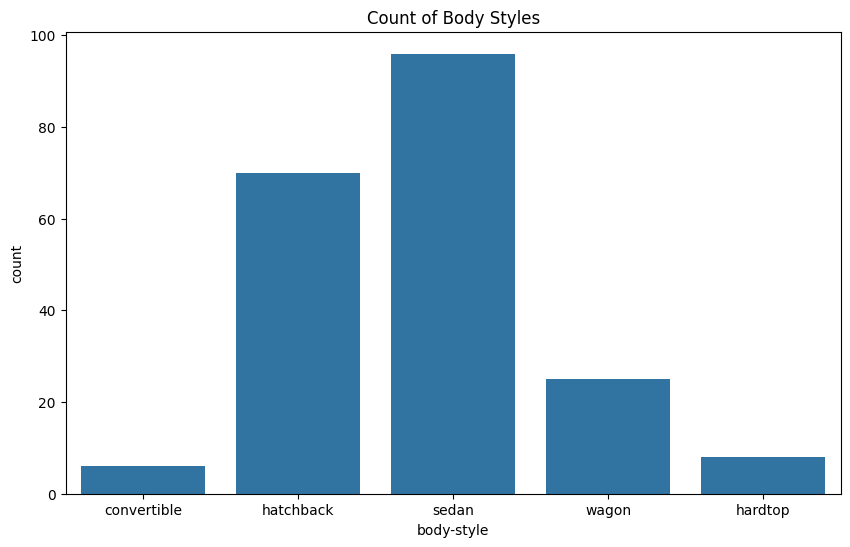

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import euclidean

# 1. Load and Clean Dataset
df = pd.read_csv('/content/Automobile_data (1).csv')
df.replace('?', np.nan, inplace=True)

# Convert numeric columns
numeric_cols = ['normalized-losses', 'wheel-base', 'length', 'width', 'height', 'curb-weight',
                'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower',
                'peak-rpm', 'city-mpg', 'highway-mpg', 'price']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. EDA: Plots
plt.figure(figsize=(10, 6))
sns.histplot(df['price'].dropna(), kde=True)
plt.title('Distribution of Price')
plt.savefig('price_distribution.png')

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='body-style')
plt.title('Count of Body Styles')
plt.savefig('body_style_count.png')

# 3. Numeric Dissimilarity (Euclidean Distance on Normalized Data)
scaler = MinMaxScaler()
numeric_data = df[['price', 'horsepower']].dropna()
numeric_scaled = scaler.fit_transform(numeric_data)
dist_numeric = euclidean(numeric_scaled[0], numeric_scaled[1])
print(f"Numeric Dissimilarity: {dist_numeric}")

# 4. Nominal Dissimilarity (Simple Mismatch)
def nominal_dissimilarity(val1, val2):
    return 0 if val1 == val2 else 1

nominal_data = df[['make', 'body-style']]
dist_nominal = nominal_dissimilarity(nominal_data.iloc[0]['make'], nominal_data.iloc[1]['make']) + \
               nominal_dissimilarity(nominal_data.iloc[0]['body-style'], nominal_data.iloc[1]['body-style'])
print(f"Nominal Dissimilarity: {dist_nominal}")